# Dykstra vs POCS

We compare projection iterates for convex and non-convex set pairs.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

import ipywidgets as widgets
def proj_disk(x, c=np.array([0.,0.]), r=1.0):
    d = x-c; n = np.linalg.norm(d)
    return c + d * min(1.0, r/(n+1e-12))

def proj_disk2(x): return proj_disk(x, np.array([1.1,0.]), 1.0)
def proj_line(x): return np.array([x[0], 0.4*x[0]-0.2])
def proj_circle(x): return proj_disk(x, np.array([0.8,0.6]), 0.9)

def run_pair(x0, p1, p2, K=35, dyk=True):
    x = x0.copy(); seq=[x.copy()]
    p = np.zeros(2); q = np.zeros(2)
    for _ in range(K):
        if dyk:
            y = p1(x+p); p = x+p-y
            x = p2(y+q); q = y+q-x
        else:
            x = p2(p1(x))
        seq.append(x.copy())
    return np.array(seq)

inits = [np.array([-1.5,1.2]), np.array([1.8,1.3]), np.array([1.6,-1.2])]


## First 5 iterates and limits for three initial points


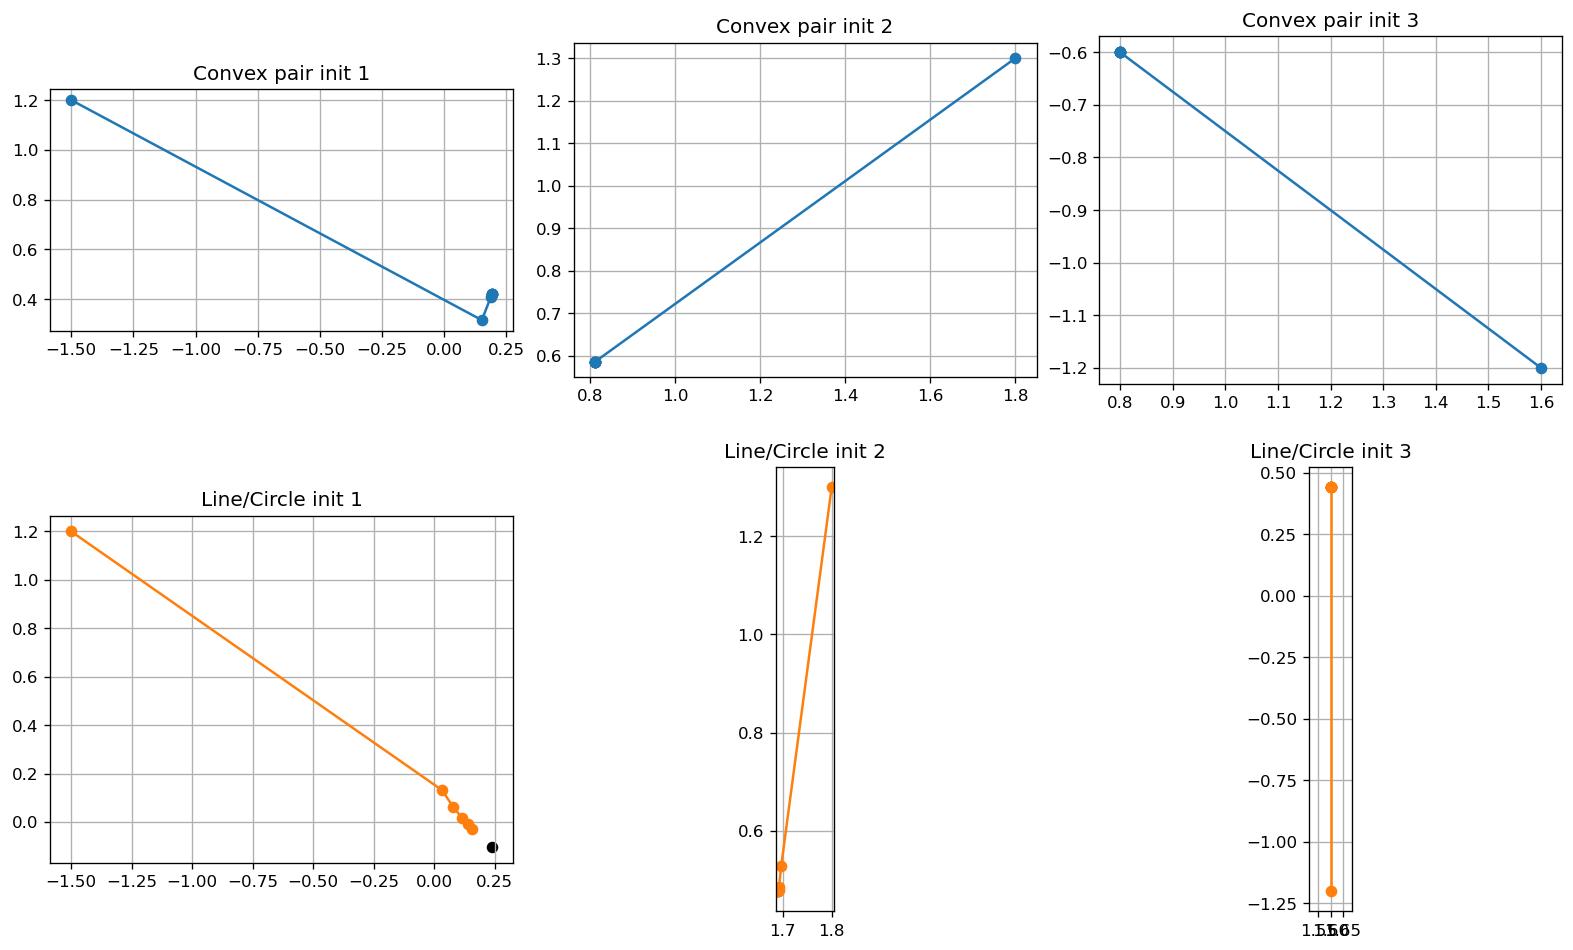

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
for c, x0 in enumerate(inits):
    s1 = run_pair(x0, lambda z: proj_disk(z,np.array([0,0]),1.0), proj_disk2, K=35, dyk=True)
    axes[0,c].plot(s1[:6,0], s1[:6,1], 'o-', color='tab:blue', lw=1.5)
    axes[0,c].scatter(s1[-1,0], s1[-1,1], c='k', s=35)
    axes[0,c].set_title(f"Convex pair init {c+1}")
    s2 = run_pair(x0, proj_line, proj_circle, K=35, dyk=True)
    axes[1,c].plot(s2[:6,0], s2[:6,1], 'o-', color='tab:orange', lw=1.5)
    axes[1,c].scatter(s2[-1,0], s2[-1,1], c='k', s=35)
    axes[1,c].set_title(f"Line/Circle init {c+1}")
for ax in axes.ravel():
    ax.set_aspect('equal')
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()


## Interactive: rotate initialization, Dykstra vs POCS
